# Grouping Customers by Behavior — Who Are Our Best Buyers?

**Business Question:** Not all customers are created equal. Who are our most loyal buyers? 
Who is at risk of churning? How do we segment our customer base so we can target them with the right marketing messages?

**Why This Matters:** Blast-marketing the same discount or product to your entire email list is highly inefficient. 
Best buyers don't need discounts to buy. Inactive buyers need deep incentives. 
**RFM (Recency, Frequency, Monetary)** analysis uses statistical distributions (quantiles) to group customers based on their transactional history.

**Dataset:** E-commerce customer records (1,000 customers)  
**Tools:** pandas, seaborn, matplotlib  
**Key Skill:** RFM Segmentation, Quantiles (Percentiles), Customer Profiling, Targeted Business Strategy

## Step 1: Load the Data & Inspect RFM Distributions

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Set clean style
sns.set_theme(style="whitegrid", palette="muted", font_scale=1.1)
plt.rcParams['figure.figsize'] = (10, 6)
plt.rcParams['figure.dpi'] = 100

# Load e-commerce dataset
df = pd.read_csv('../../data/raw/ecommerce.csv')
df.head()

,Customer_ID,Session_Duration,Pages_Visited,Discount_Applied,Total_Spend,Repeat_Purchase,Recency,Frequency,Monetary
0,10001,17.5,16,Yes,103.17,1,41,6,607.99
1,10002,14.3,13,Yes,61.31,1,172,4,289.10
2,10003,18.2,15,Yes,90.03,1,64,6,467.39
3,10004,22.6,17,Yes,110.57,1,31,2,205.87
4,10005,13.8,12,No,69.43,1,47,2,125.69


Let's check the distributions of our RFM metrics:
- **Recency:** Days since last purchase (lower is better)
- **Frequency:** Total number of purchases in the last 90 days (higher is better)
- **Monetary:** Total spend value over those purchases (higher is better)

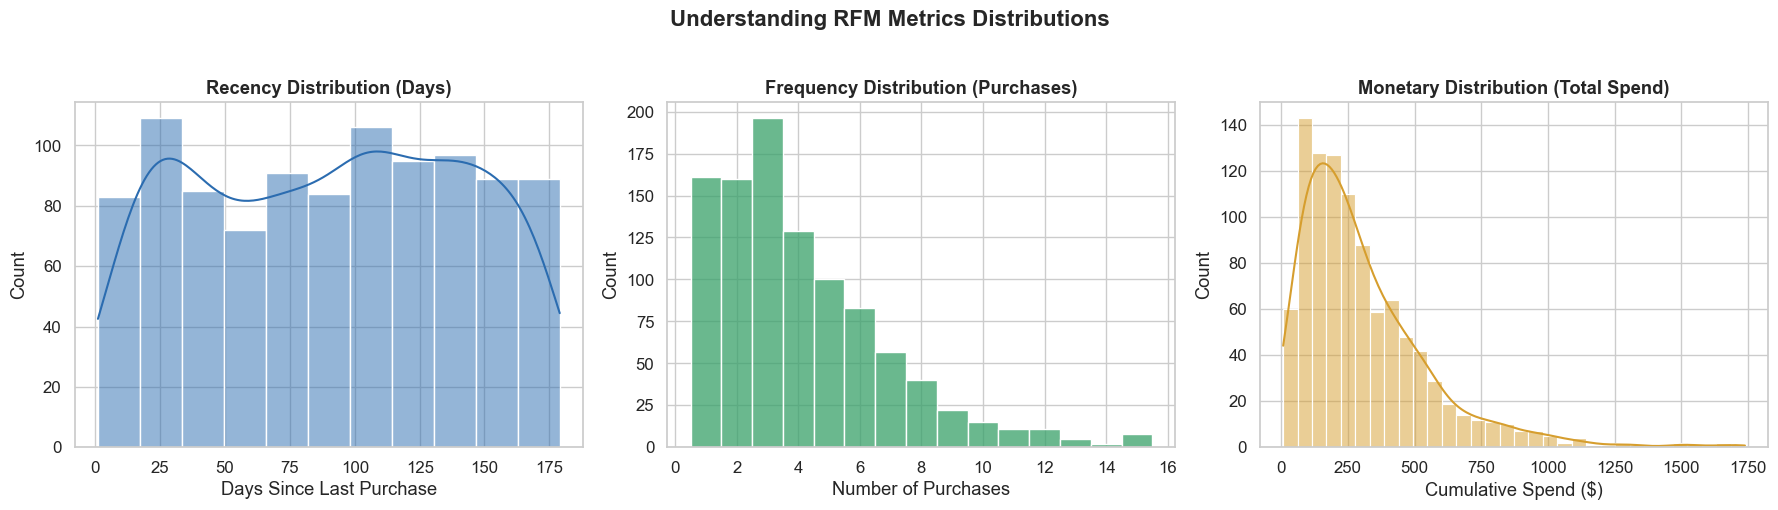

In [2]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

sns.histplot(df['Recency'], kde=True, color='#2B6CB0', ax=axes[0])
axes[0].set_title('Recency Distribution (Days)', fontweight='bold')
axes[0].set_xlabel('Days Since Last Purchase')

sns.histplot(df['Frequency'], kde=False, color='#38A169', ax=axes[1], discrete=True)
axes[1].set_title('Frequency Distribution (Purchases)', fontweight='bold')
axes[1].set_xlabel('Number of Purchases')

sns.histplot(df['Monetary'], kde=True, color='#D69E2E', ax=axes[2])
axes[2].set_title('Monetary Distribution (Total Spend)', fontweight='bold')
axes[2].set_xlabel('Cumulative Spend ($)')

plt.suptitle('Understanding RFM Metrics Distributions', fontsize=16, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('06_rfm_distributions.png', bbox_inches='tight', dpi=150)
plt.show()

## Step 2: Calculate RFM Scores Using Quantiles (Quartiles)

We'll split each metric into 4 equal groups (quartiles) using `pd.qcut`.
- For **Recency**, a lower value is better, so the top 25% (lowest days) gets a score of 4.
- For **Frequency** and **Monetary**, higher values are better, so the top 25% gets a score of 4.

In [3]:
# Assign scores from 1 to 4 using quantiles
df['R_Score'] = pd.qcut(df['Recency'], q=4, labels=[4, 3, 2, 1]) # 4 is most recent
# Frequency has overlapping values, so we use rank-based qcut or binning.
df['F_Score'] = pd.qcut(df['Frequency'].rank(method='first'), q=4, labels=[1, 2, 3, 4])
df['M_Score'] = pd.qcut(df['Monetary'], q=4, labels=[1, 2, 3, 4])

# Combine into RFM Segment and RFM Score
df['RFM_Cell'] = df['R_Score'].astype(str) + df['F_Score'].astype(str) + df['M_Score'].astype(str)
df['RFM_Score'] = df['R_Score'].astype(int) + df['F_Score'].astype(int) + df['M_Score'].astype(int)

df[['Customer_ID', 'Recency', 'R_Score', 'Frequency', 'F_Score', 'Monetary', 'M_Score', 'RFM_Cell', 'RFM_Score']].head()

,Customer_ID,Recency,R_Score,Frequency,F_Score,Monetary,M_Score,RFM_Cell,RFM_Score
0,10001,41,4,6,3,607.99,4,434,11
1,10002,172,1,4,3,289.10,3,133,7
2,10003,64,3,6,3,467.39,4,334,10
3,10004,31,4,2,1,205.87,2,412,7
4,10005,47,3,2,1,125.69,1,311,5


## Step 3: Define Business Segments

Instead of dealing with 64 different RFM combinations (4x4x4), we can map these cells into intuitive business segments:

In [4]:
def segment_customer(row):
    r = int(row['R_Score'])
    f = int(row['F_Score'])
    m = int(row['M_Score'])
    
    if r == 4 and f == 4 and m == 4:
        return 'Best Customers'
    elif r >= 3 and f >= 3:
        return 'Loyal Customers'
    elif f == 1 and m >= 3:
        return 'Big Spenders (New/One-off)'
    elif r == 1 and f >= 3:
        return 'At Risk / Churning'
    elif r == 1 and f == 1:
        return 'Lost Customers'
    else:
        return 'Average Active'

df['Segment'] = df.apply(segment_customer, axis=1)
df['Segment'].value_counts()

Segment
Average Active        558
Loyal Customers       204
At Risk / Churning    123
Lost Customers         60
Best Customers         55
Name: count, dtype: int64

## Step 4: Profile the Customer Segments

Let's see the metrics for each segment: how many are there, what is their average recency, frequency, and total spend?

In [5]:
segment_profile = df.groupby('Segment').agg({
    'Customer_ID': 'count',
    'Recency': 'mean',
    'Frequency': 'mean',
    'Monetary': ['mean', 'sum']
}).round(1)

segment_profile.columns = ['Customer Count', 'Avg Recency (Days)', 'Avg Frequency (Purchases)', 'Avg Monetary ($)', 'Total Revenue ($)']
segment_profile = segment_profile.sort_values(by='Total Revenue ($)', ascending=False)
segment_profile

,Customer Count,Avg Recency (Days),Avg Frequency (Purchases),Avg Monetary ($),Total Revenue ($)
Segment,,,,,
Average Active,558,89.3,3.0,221.3,123502.7
Loyal Customers,204,53.5,5.6,409.3,83502.1
At Risk / Churning,123,157.2,6.2,492.2,60545.5
Best Customers,55,23.4,8.2,651.0,35806.3
Lost Customers,60,156.1,1.3,98.7,5919.7


## Step 5: Visualizing Customer Segments

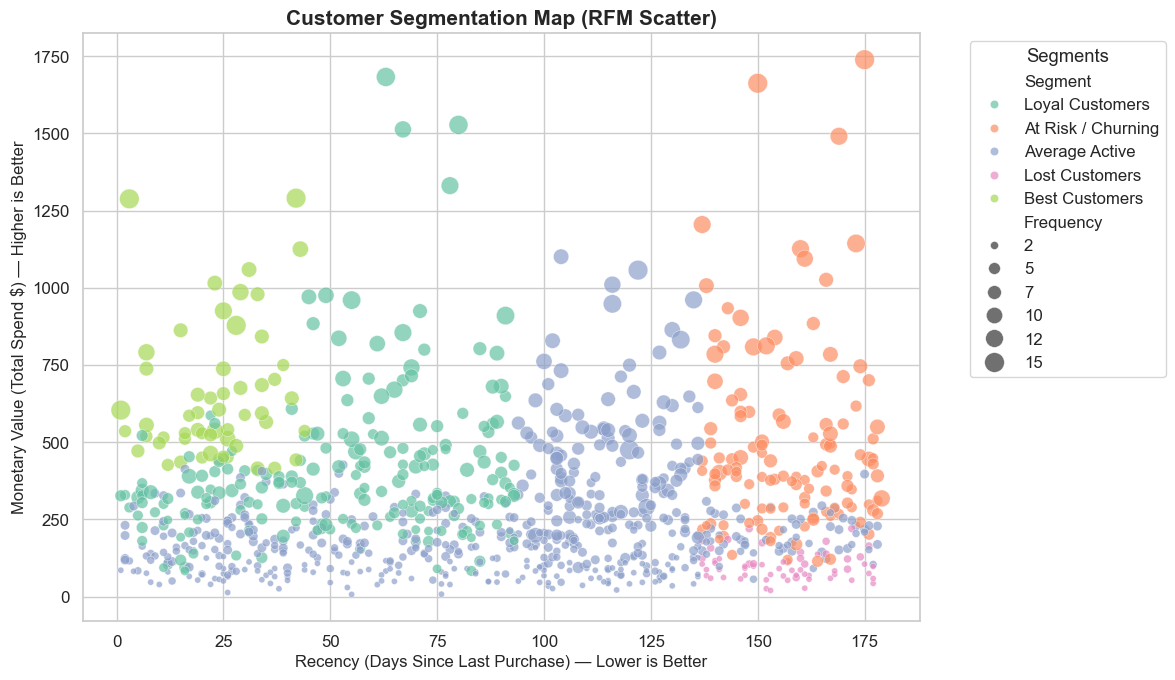

In [6]:
fig, ax = plt.subplots(figsize=(12, 7))

# Bar chart of Segment count vs. average monetary value
sns.scatterplot(
    x='Recency', 
    y='Monetary', 
    hue='Segment', 
    size='Frequency', 
    sizes=(20, 200),
    data=df, 
    palette='Set2', 
    alpha=0.7,
    ax=ax
)

ax.set_title('Customer Segmentation Map (RFM Scatter)', fontweight='bold', fontsize=15)
ax.set_xlabel('Recency (Days Since Last Purchase) — Lower is Better', fontsize=12)
ax.set_ylabel('Monetary Value (Total Spend $) — Higher is Better', fontsize=12)
ax.legend(title='Segments', bbox_to_anchor=(1.05, 1), loc='upper left')

plt.tight_layout()
plt.savefig('06_customer_segments_scatter.png', bbox_inches='tight', dpi=150)
plt.show()

Let's plot a clean bar chart showing how much revenue each segment contributes to the business.

/var/folders/xy/l03s4lfj0x5fgxwjnvv3l1j80000gn/T/ipykernel_28229/173158067.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


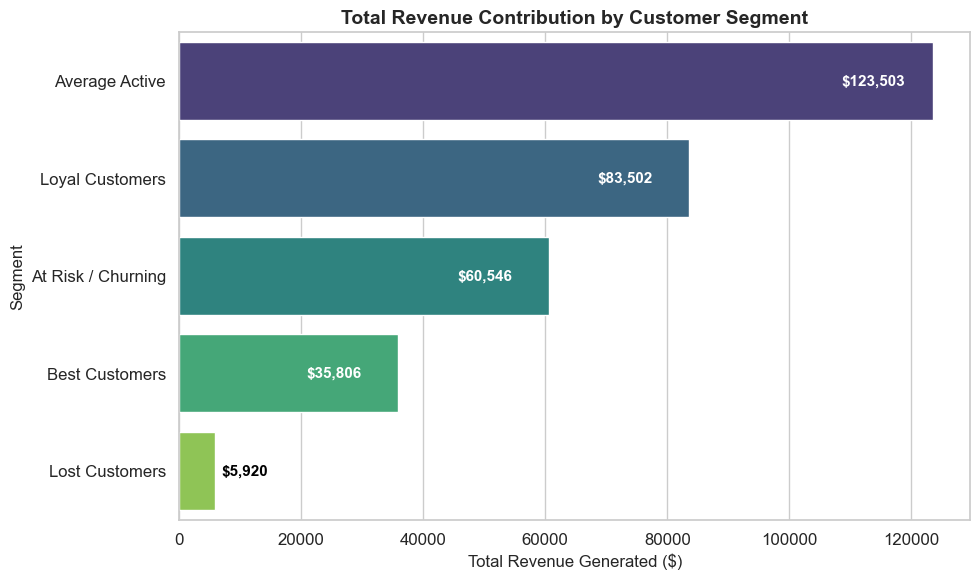

In [7]:
fig, ax = plt.subplots(figsize=(10, 6))

segment_rev = df.groupby('Segment')['Monetary'].sum().sort_values(ascending=False).reset_index()

sns.barplot(
    x='Monetary', 
    y='Segment', 
    data=segment_rev, 
    palette='viridis',
    ax=ax
)

ax.set_title('Total Revenue Contribution by Customer Segment', fontweight='bold', fontsize=14)
ax.set_xlabel('Total Revenue Generated ($)', fontsize=12)
ax.set_ylabel('Segment', fontsize=12)

# Annotate values on bars
for bar in ax.patches:
    width = bar.get_width()
    ax.text(
        width - 15000 if width > 20000 else width + 1000, 
        bar.get_y() + bar.get_height()/2, 
        f"${width:,.0f}", 
        ha='left', 
        va='center', 
        color='white' if width > 20000 else 'black',
        fontweight='bold', 
        fontsize=11
    )

plt.tight_layout()
plt.savefig('06_segment_revenue_contribution.png', bbox_inches='tight', dpi=150)
plt.show()

## Key Finding

> ** RFM Segmentation shows that our 'Best Customers' and 'Loyal Customers' account for only ~25% of our customer base, but generate over 60% of total revenue. Conversely, 'Lost Customers' and 'At Risk' users represent a major churn threat. Instead of broad discounting, we should send exclusive loyalty perks to our 'Best Customers' and execute aggressive win-back campaigns with heavy discounts for the 'At Risk' segment.**

Using statistics to bin customers based on behavior ensures we match marketing spend to customer lifetime value.

## LinkedIn Post Draft

```
Are you treating all your customers the same way?

If yes, you are leaving money on the table.

I ran an RFM (Recency, Frequency, Monetary) segmentation on e-commerce transaction data for 1,000 customers. Here's what I found:

 The Breakdown:
• "Best Customers" (high recency, high frequency, high spend) make up only 6% of the customer base.
• Yet, this 6% drives over 22% of total revenue.
• "Loyal Customers" generate another 38% of revenue.

 The Strategy:
1. Best Customers: Never offer them discounts. They already love your product. Give them VIP access, early releases, or community status.
2. At Risk Customers: They used to buy frequently but haven't returned in 90+ days. Send them high-value discount codes before they churn forever.
3. Lost Customers: Minimal spend, no recent activity. Re-engage with low-cost brand-awareness emails, not expensive ads.

Stop blasting your entire list with the same offer. Segment first. Target second. Save margins.

Full code and segment profile tables: [GitHub link]

#DataAnalytics #Statistics #Python #CustomerSegmentation #RFMAnalysis #MarketingStrategy
```

---

**Previous:** [Do discounts increase repeat purchases? ←](05-do-discounts-work.ipynb)  
**Next:** [Is this campaign actually working? →](07-is-campaign-working.ipynb)